In [79]:
%pip install "numpy<2"

  Obtaining dependency information for numpy<2 from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 330.3 kB/s eta 0:00:01
     ------------------------------- ------ 51.2/61.0 kB 525.1 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 466.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   - -------------------------------------- 0.4/15.8 MB 8.7 MB/s eta 0:00:02
   --- ------------------------------------ 1.5/15.8 MB 15.5 MB/s eta 0:00:01
   ------- -------------------------------- 3.1/15.8 MB 22.2 MB/s eta 0:00:01
   ------------ --------------------------- 5.0/15.8 MB 26.3 MB/s eta 0:00:01
   ------------------- -------------------- 7.7/15.8 MB 32.8 MB/s eta 0:00:01
   -------------------

ERROR: Could not install packages due to an OSError: [WinError 5] Zugriff verweigert: 'C:\\Users\\quicken\\AppData\\Local\\anaconda3\\Lib\\site-packages\\~umpy.libs\\libscipy_openblas64_-63c857e738469261263c764a36be9436.dll'
Consider using the `--user` option or check the permissions.



In [37]:
import cv2
import numpy as np

colors = {
    "mouse1": (255, 0, 255),     # magenta
    "mouse2": (0, 255, 255),     # yellow
    "mouse3": (255, 255, 0),     # cyan
}

def draw_dlc_keypoints(
    df,
    video_path,
    output_path,
    point_size=5,
    colors=None,
    likelihood_threshold=0.0,
    start_frame=0,
    end_frame=None
):
    """
    Draw DLC keypoints into a selected frame range of a video.

    Parameters
    ----------
    df : pd.DataFrame
        DeepLabCut dataframe with MultiIndex columns.

    video_path : str
        Path to input video.

    output_path : str
        Path for annotated output video.

    point_size : int
        Radius of drawn keypoints.

    colors : dict or None
        Color per individual in BGR format.

    likelihood_threshold : float
        Keypoints below this likelihood are not drawn.

    start_frame : int
        First frame to include.

    end_frame : int or None
        Last frame to include (exclusive).
        If None, video is processed until the end.
    """

    if "scorer" in df.columns.names:
        df = df.droplevel("scorer", axis=1)

    individuals = df.columns.get_level_values("individuals").unique()
    bodyparts = df.columns.get_level_values("bodyparts").unique()

    default_colors = [
        (0, 0, 255),
        (0, 255, 0),
        (255, 0, 0),
        (0, 255, 255),
        (255, 0, 255),
        (255, 255, 0),
    ]

    if colors is None:
        colors = {
            ind: default_colors[i % len(default_colors)]
            for i, ind in enumerate(individuals)
        }

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if end_frame is None:
        end_frame = min(video_frames, len(df))

    end_frame = min(end_frame, video_frames, len(df))

    if start_frame < 0 or start_frame >= end_frame:
        raise ValueError(
            f"Invalid frame range: start_frame={start_frame}, "
            f"end_frame={end_frame}"
        )

    writer = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*"XVID"),
        fps,
        (width, height)
    )

    # Jump directly to selected start frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    frame_idx = start_frame

    while frame_idx < end_frame:

        ret, frame = cap.read()

        if not ret:
            break

        row = df.iloc[frame_idx]

        for ind in individuals:

            color = colors[ind]

            for bp in bodyparts:

                try:
                    x = row[(ind, bp, "x")]
                    y = row[(ind, bp, "y")]
                    likelihood = row[(ind, bp, "likelihood")]

                except KeyError:
                    continue

                if (
                    likelihood >= likelihood_threshold
                    and np.isfinite(x)
                    and np.isfinite(y)
                ):
                    cv2.circle(
                        frame,
                        (int(x), int(y)),
                        point_size,
                        color,
                        -1
                    )

        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()

    print(
        f"Saved frames {start_frame}–{end_frame - 1} "
        f"to: {output_path}"
    )

In [18]:
import glob as glob
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import shutil
from variables import FPS

**Reading in DeepLabCut Data**

First, we have to read in the data DeepLabCut provides. This is most easily done by using the .h5 files.

In [30]:
folder = r"Z:\n2023_odor_related_behavior\other\Vorträge\261002_Coders_Club"
file = r"multi_animal_example.h5"
file_path = os.path.join(folder, file)

df = pd.read_hdf(file_path)

**There is multi-animal and single-animal deeplabcut!**

This changes the structure of the dataframe we read in.

We just read in a multi animal dataframe:

In [21]:
#df.head()
print(df.columns.nlevels)
print(df.columns.names)

4
['scorer', 'individuals', 'bodyparts', 'coords']


While a single animal dataframe is missing the "individuals" column:

In [22]:
sa_df = pd.read_hdf(r"Z:\n2023_odor_related_behavior\other\Vorträge\261002_Coders_Club\single_animal_example.h5")

print(sa_df.columns.nlevels)
print(sa_df.columns.names)

3
['scorer', 'bodyparts', 'coords']


**Multi-index information of DeepLabCut**

The Header of Deeplabcut indicates the data hierarchy and informs us about what data is stored.

In [42]:
for name in df.columns.names:
    unique_values = df.columns.get_level_values(name).unique()

    print(name, unique_values.to_list())

scorer ['DLC_HrnetW32_multi_animal_mmoNov19shuffle1_detector_best-330_snapshot_best-20']
individuals ['mouse1', 'mouse2', 'mouse3']
bodyparts ['nose', 'eye_left', 'eye_right', 'left_ear', 'right_ear', 'head_centre', 'dorsal_1', 'dorsal_2', 'dorsal_3', 'dorsal_4', 'shoulder_left', 'shoulder_right', 'lateral_left', 'lateral_right', 'hip_left', 'hip_right', 'tail_base']
coords ['x', 'y', 'likelihood']


**Slicing**

Using pandas we can *flexibly* slice our dataframe, so we can easily take only the data we are interested in.

In [4]:
scorer = df.columns.get_level_values("scorer").unique()
individuals = df.columns.get_level_values("individuals").unique()
bodyparts = df.columns.get_level_values("bodyparts").unique()
coords = df.columns.get_level_values("coords").unique()

lh_df = df.loc[:, (scorer, individuals, bodyparts, "likelihood")]
lh_df.head()

scorer      DLC_HrnetW32_multi_animal_mmoNov19shuffle1_detector_best-330_snapshot_best-20  \
individuals                                                                        mouse1   
bodyparts                                                                            nose   
coords                                                                         likelihood   
0                                                     0.571777                              
1                                                     0.593750                              
2                                                     0.788086                              
3                                                     0.800293                              
4                                                     0.810059                              

scorer                                                               \
individuals                                                           
bodyparts     eye_left  eye_right   left_ear  right_ear head_centre   
coords      likelihood likelihood likelihood likelihood  likelihood   
0             0.436035   0.418213   0.259766   0.410400    0.455811   
1             0.544922   0.843750   0.800293   0.790039    0.672852   
2             0.590820   0.958984   0.853027   0.812500    0.665527   
3             0.736816   0.915527   0.851074   0.854980    0.765625   
4             0.776855   0.748047   0.870117   0.937988    0.772461   

scorer                                                   ...             \
individuals                                              ...     mouse3   
bodyparts     dorsal_1   dorsal_2   dorsal_3   dorsal_4  ...   dorsal_2   
coords      likelihood likelihood likelihood likelihood  ... likelihood   
0             0.323486   0.076843   0.107727   0.151855  ...        NaN   
1             0.261475   0.102600   0.120117   0.174072  ...        NaN   
2             0.587891   0.089722   0.112488   0.177368  ...        NaN   
3             0.632812   0.135376   0.095337   0.171631  ...        NaN   
4             0.679199   0.757324   0.115601   0.132568  ...        NaN   

scorer                                                                       \
individuals                                                                   
bodyparts     dorsal_3   dorsal_4 shoulder_left shoulder_right lateral_left   
coords      likelihood likelihood    likelihood     likelihood   likelihood   
0                  NaN        NaN           NaN            NaN          NaN   
1                  NaN        NaN           NaN            NaN          NaN   
2                  NaN        NaN           NaN            NaN          NaN   
3                  NaN        NaN           NaN            NaN          NaN   
4                  NaN        NaN           NaN            NaN          NaN   

scorer                                                      
individuals                                                 
bodyparts   lateral_right   hip_left  hip_right  tail_base  
coords         likelihood likelihood likelihood likelihood  
0                     NaN        NaN        NaN        NaN  
1                     NaN        NaN        NaN        NaN  
2                     NaN        NaN        NaN        NaN  
3                     NaN        NaN        NaN        NaN  
4                     NaN        NaN        NaN        NaN  

[5 rows x 51 columns]

(array([ 2674.,  2391.,  1979.,  2742.,  4128.,  7696., 15159., 37860.,
        61414., 35011.]),
 array([0.00777435, 0.10699692, 0.20621948, 0.30544205, 0.40466461,
        0.50388718, 0.60310974, 0.70233231, 0.80155487, 0.90077744,
        1.        ]),
 <BarContainer object of 10 artists>)

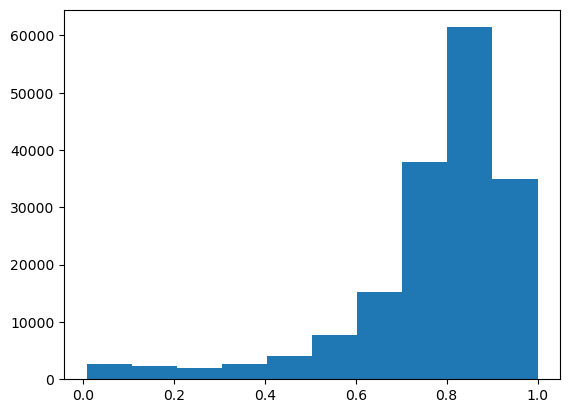

In [10]:
import matplotlib.pyplot as plt

plt.hist(lh_df.to_numpy().ravel())


**Let's check how DeepLabCut performed in labelling our mice.**

In [ ]:
video = r"multi_animal_example.avi"
video_path = os.path.join(folder, video)
start_frame = 450
end_frame = 1260

draw_dlc_keypoints(
    df=df,
    video_path=video_path,
    output_path=os.path.join(folder, "video_keypoints.avi"),
    point_size=6,
    colors=colors,
    start_frame=start_frame,
    end_frame=end_frame
)

Saved frames 450–1259 to: Z:\n2023_odor_related_behavior\other\Vorträge\261002_Coders_Club\video_keypoints.avi


**We see some weird labels, let's check how certain the prediction is of the network.**

DeepLabCut provides for each keypoint a likelihood, how "sure" the network is about its prediction. 

Low likelihood values can indicate worse predictions, so we might want to get rid of them to increase the data quality.

Text(0, 0.5, 'frame count')

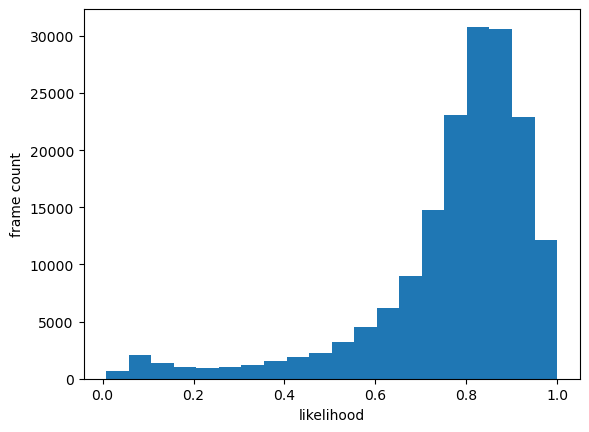

In [21]:
import matplotlib.pyplot as plt

# first put all likelihoods into a one-dimensional numpy array for better visualization
all_likelihoods = lh_df.to_numpy().ravel()

plt.hist(all_likelihoods, bins=20) # bin size of 5%
plt.xlabel("likelihood")
plt.ylabel("frame count")

**Masking**

In pandas, we can adjust the values of our dataframe in a logical way, for example to filter bad predictions.


Let's set the filter value to 0.6, so predictions lower than 60% certainty get filtered

In [36]:
# create a copy to not alter the original df
filtered_df = df.copy()

filter_value = 0.6

# let's save how many keypoints are getting removed for our video snippet
filtered_keypoints = 0
total_keypoints = 0

# Because we have a likelihood for each bodypart of each individuum, we have to loop over the columns we want to change
for ind in individuals:
    for bp in bodyparts:
        #likelihood = df.loc[:, (scorer, ind, bp, "likelihood")]   # <-- using df.loc yields a dataframe, but for masking we need an array

        # based on our slicing, we know that 'likelihood' is one-dimensional, so we can
        # use .squeeze() to create a pandas.Series, which is similar to an array
        likelihood = df.loc[:, (scorer, ind, bp, "likelihood")].squeeze()

        # we create a mask containing True of False, depending on our filter_value for each frame
        mask = likelihood <= filter_value

        # using the mask, we can select each row that is True and update the df, so the x and y coordinates are set to "np.nan"
        filtered_df.loc[mask, (scorer, ind, bp, ["x", "y"])] = np.nan

        # update how many keypoints got filtered
        filtered_keypoints += sum(mask[start_frame:end_frame])
        total_keypoints += end_frame-start_frame

percent_filtered = filtered_keypoints/total_keypoints * 100
percent_filtered = round(percent_filtered, 2)

print(f"Filtered keypoint labels: {filtered_keypoints}\n"
      f"Total keypoints: {total_keypoints}\n"
      f"Percent filtered: {percent_filtered} %")
   

Filtered keypoint labels: 4605
Total keypoints: 41310
Percent filtered: 11.15 %


**Now we see how the video looks with the removed keypoints**

In [38]:
draw_dlc_keypoints(
    df=filtered_df,
    video_path=video_path,
    output_path=os.path.join(folder, "video_keypoints_filtered.avi"),
    point_size=6,
    colors=colors,
    start_frame=start_frame,
    end_frame=end_frame
)

Saved frames 450–1259 to: Z:\n2023_odor_related_behavior\other\Vorträge\261002_Coders_Club\video_keypoints_filtered.avi


**Using Interpolation to rescue some of the missing data**

In [40]:

def interpolate_with_max_gap(df, max_gap=30, method="linear"):
    
    out = df.copy()

    coords = out.columns.get_level_values("coords")
    interpolation_cols = out.columns[coords.isin(["x", "y"])]

    out[interpolation_cols] = out[interpolation_cols].interpolate(
        method=method,
        limit_direction="both",
        limit_area="inside"
    )

    for col in interpolation_cols:

        s = df[col]

        grp = s.notna().cumsum()
        run_len = s.isna().groupby(grp).transform("sum")

        too_long = s.isna() & (run_len > max_gap)

        out.loc[too_long, col] = np.nan

    return out

In [42]:
interpolated_df = interpolate_with_max_gap(filtered_df)
draw_dlc_keypoints(
    df=interpolated_df,
    video_path=video_path,
    output_path=os.path.join(folder, "video_keypoints_interpolated.avi"),
    point_size=6,
    colors=colors,
    start_frame=start_frame,
    end_frame=end_frame
)

Saved frames 450–1259 to: Z:\n2023_odor_related_behavior\other\Vorträge\261002_Coders_Club\video_keypoints_interpolated.avi
